# Analyze A/B Test Results 

- [Introduction](#intro)
- [Part I - Probability](#probability)
- [Part II - A/B Test](#ab_test)
- [Part III - Regression](#regression)
- [Final Check](#finalcheck)
- [Submission](#submission)

<a id='intro'></a>
## Introduction

A/B tests are very commonly performed by data analysts and data scientists. This project will run an A/B test and work to understand if a company should: 
- Implement new webpage
- Keep the old webpage
- Keeping running the experiment before making decision

<a id='probability'></a>
## Part I - Probability

In [122]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline

### ToDo 1.1
The data will be read and then stored in the dataframe df. Below is a description of the data, there are a total of 5 columns: 


<center>

|Data columns|Purpose|Valid values|
| ------------- |:-------------| -----:|
|user_id|Unique ID|Int64 values|
|timestamp|Time stamp when the user visited the webpage|-|
|group|In the current A/B experiment, the users are categorized into two broad groups. <br>The `control` group users are expected to be served with `old_page`; and `treatment` group users are matched with the `new_page`. <br>However, **some inaccurate rows** are present in the initial data, such as a `control` group user is matched with a `new_page`. |`['control', 'treatment']`|
|landing_page|It denotes whether the user visited the old or new webpage.|`['old_page', 'new_page']`|
|converted|It denotes whether the user decided to pay for the company's product. Here, `1` means yes, the user bought the product.|`[0, 1]`|
</center>

In [123]:
df = pd.read_csv('ab_data.csv')
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [124]:
df.shape

(294478, 5)

The number of unique users in the dataset.

In [125]:
df['user_id'].nunique()

290584

The proportion of users converted.

In [126]:
df.converted.mean()

0.11965919355605512

The number of times when the "group" is `treatment` but "landing_page" is not a `new_page`.

In [127]:
df.user_id[(df['group'] == 'treatment') & (df['landing_page'] != 'new_page')].count()

1965

In [128]:
# checking for missing values
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


### ToDo 1.2  
In a particular row, the **group** and **landing_page** columns should have either of the following acceptable values:

|user_id| timestamp|group|landing_page|converted|
|---|---|---|---|---|
|XXXX|XXXX|`control`| `old_page`|X |
|XXXX|XXXX|`treatment`|`new_page`|X |


It means, the `control` group users should match with `old_page`; and `treatment` group users should matched with the `new_page`. 

However, for the rows where `treatment` does not match with `new_page` or `control` does not match with `old_page`, we cannot be sure if such rows truly received the new or old wepage. Because of this all of these rows will be dropped and a new dataframe will be created called **df2**. 

In [129]:
# removes inaccurate rows 
df2 = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) | ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))]

In [130]:
# checks that inaccurate rows are removed
# should return 0 
df2[((df2['group'] == 'treatment') == (df2['landing_page'] == 'new_page')) == False].shape[0]

0

### ToDo 1.3  

The number of unique users in **df2**. 

In [131]:
df2['user_id'].nunique()

290584

Shows duplicated rows. 

In [132]:
df2[df2['user_id'].duplicated()]

,user_id,timestamp,group,landing_page,converted
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


Displays duplicate rows.

In [133]:
df2[df2['user_id'] == 773192]

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


**d.** Removes **one** of the rows with a duplicate **user_id**, from the **df2** dataframe.

In [134]:
# Removes one of the rows with a duplicate user_id.
df2 = df2.drop([2893])
# Checks that duplicate row is deleted 
df2[df2['user_id'] == 773192]

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0


### ToDo 1.4  
Probability of converting regardless of page received. 

In [135]:
prob_convert = df2.converted.mean()
prob_convert

0.11959708724499628

Probability of converting if in the `control` group. 

In [136]:
prob_control_convert = df2.converted[df2['group'] == 'control'].mean()
prob_control_convert

0.1203863045004612

Probability of converting if in the `treatment` group.

In [137]:
prob_treatment_convert = df2.converted[df2['group'] == 'treatment'].mean()
prob_treatment_convert

0.11880806551510564

The probility of converting can be treated as a conversion rate. Below is the difference in conversion between the treatment and control group.

In [138]:
actual_conversion_diff = prob_treatment_convert - prob_control_convert
actual_conversion_diff

-0.0015782389853555567

The probability that an individual received the new page.

In [139]:
new_page_prob = df2.landing_page[df2['landing_page'] == 'new_page'].count() / df2['landing_page'].count()
new_page_prob  

0.5000619442226688

##### The new treatment group does not lead to more users although it should be noted that there is very little difference between the control and treatment group and that the results are likely not statistically significant. 

<a id='ab_test'></a>
## Part II - A/B Test

Since a timestamp is associated with each event, a hypothesis test can be run continuously as long as the events are observed.

If that is the case then: 
- should the test be stopped as soon as one page is considered significantly better than another or does it need to happen consistently for a certain amount of time? 
- how long does the test need to run in order to decide that neither page is better? 

These questions are the difficult parts associated with A/B tests in general.  


### ToDo 2.1
For now, a decision will be made based on the data provided. 

Assuming that the old page is better unless the new page proves to be definitely better at a Type I error rate of 5% the null and alternative hypothesises are: 

NULL: The conversion rate of the new page is equal to or less than that of the old page.  

ALTERNATIVE: The conversion rate of the new page is greater than the old page.  

### ToDo 2.2 - Null Hypothesis $H_0$ Testing
Under the null hypothesis $H_0$, assume that $p_{new}$ and $p_{old}$ are equal. Furthermore, assume that $p_{new}$ and $p_{old}$ both are equal to the **converted** success rate in the `df2` data regardless of the page. So, our assumption is: <br><br>
<center>
$p_{new}$ = $p_{old}$ = $p_{population}$
</center>

In this section: 

- bootstrap samples will be created for the control and treatment groups, and the  "converted" probability $p$ for those samples will be calcuated 


- the bootstrap samples will be the same size as their respective groups in the original dataset


- the difference in the "converted" probability for the two samples above will be calculated


- this will be performed 10,000 times

The **conversion rate** for $p_{new}$ and $p_{old}$ under the null hypothesis is: 

In [140]:
prob_convert

0.11959708724499628

The number of individuals in the treatment group:

In [141]:
n_new = df2.landing_page[df2['landing_page'] == 'new_page'].count()
n_new

145310

The number of individuals in the control group: 

In [142]:
n_old = df2.landing_page[df2['landing_page'] == 'old_page'].count()
n_old

145274

**e. Bootstrap sample for the `treatment` Group**<br> 
$n_{new}$ transactions with a conversion rate of $p_{new}$ under the null hypothesis.

In [143]:
# creates an array that contains one set of possible outcomes 
# given the probability of conversion under the null hypothesis
new_page_converted = np.random.binomial(1, prob_convert, n_new)
new_page_converted

array([0, 1, 0, ..., 0, 0, 1])

**f. Bootstrap sample for the `control` Group** <br>
$n_{old}$ transactions with a conversion rate of $p_{old}$ under the null hypothesis. 

In [144]:
old_page_converted = np.random.binomial(1, prob_convert, n_old)
old_page_converted

array([0, 0, 1, ..., 0, 0, 0])

**g.** Difference between conversion rates of samples.

In [145]:
sample_diff = new_page_converted.mean() - old_page_converted.mean() 
sample_diff

-0.001371753123841274

**h. Sampling distribution** <br>
Repeated process 10,000 times and stored the differences between conversions in `conversion_diffs`. 

In [146]:
# contains 10,000 different conversion rates for treatment group (new page)
new_page_conversion_rates = np.random.binomial(n_new, prob_convert, 10000) / n_new

# contains 10,000 different conversion rates for control group (old_page)
old_page_conversion_rates = np.random.binomial(n_old, prob_convert, 10000) / n_old

In [147]:
# contains the differences of 10,000 conversion rates of both groups
conversion_diffs = new_page_conversion_rates - old_page_conversion_rates

**i. Histogram**<br> 
Histogram of the **conversion_diffs**. 

In [148]:
def freq_dist():
    plt.hist(conversion_diffs)
    plt.title('Frequency distribution of conversion differences under null hypothesis')
    plt.xlabel('conversion difference')
    plt.ylabel('Frequency')
    plt.axvline(actual_conversion_diff, c='r');

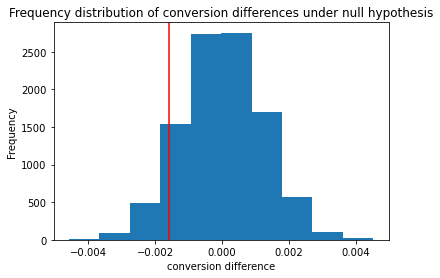

In [149]:
freq_dist()

**The red line indicates the actual conversion difference observed in the `df2` data. Everything to the right of the red line indicates the probability that the null hypothesis is true. This is because for the null hypothesis to be true the conversion difference has to be greater than the actual conversion difference observed which is marked by the red line at -0.001578. Anything less than the actual conversion difference observed would make the alternative hypothesis true and the probability of that is shown to the left of the red line.**

**j.** The proportion of **conversion_diffs** that are greate than the actual difference observed in the `df2` data is: 

In [150]:
greater_than = conversion_diffs[conversion_diffs > conversion_diff].size / conversion_diffs.size
greater_than

0.9059

**k.** Explanation of number computed above.

###### In scientific studies this value is called the p value. The p value is the probility that the null hypothesis is true. The p value above (0.9041) indicates that the old and the new page are the same based on the decided type I error rate of 0.05.

**l. Using Built-in Methods for Hypothesis Testing**<br>
The following method will repeat the same process as above using a different method that is already built in.
- `convert_old`: number of conversions with the old_page
- `convert_new`: number of conversions with the new_page
- `n_old`: number of individuals who were shown the old_page
- `n_new`: number of individuals who were shown the new_page


In [151]:
import statsmodels.api as sm

# number of conversions with the old_page
convert_old = df2.converted[(df2['group'] == 'control') & (df2['converted'] == 1)].count()

# number of conversions with the new_page
convert_new = df2.converted[(df2['group'] == 'treatment')  & (df2['converted'] == 1)].count()

# number of individuals who were shown the old_page
n_old = df2.converted[df2['group'] == 'control'].count()

# number of individuals who were shownthe new_page
n_new = df2.converted[df2['group'] == 'treatment'].count()

**m.** The `sm.stats.proportions_ztest()` is used to compute a test statistic and p-value.  [Here](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html) is a link on using the built in.

The syntax is: 
```bash
proportions_ztest(count_array, nobs_array, alternative='larger')
```
where, 
- `count_array` = represents the number of "converted" for each group
- `nobs_array` = represents the total number of observations (rows) in each group
- `alternative` = choose one of the values from `[‘two-sided’, ‘smaller’, ‘larger’]` depending upon two-tailed, left-tailed, or right-tailed respectively.<br><br>
It's a two-tailed if you defined $H_1$ as $(p_{new} = p_{old})$. <br>
It's a left-tailed if you defined $H_1$ as $(p_{new} < p_{old})$. <br>
It's a right-tailed if you defined $H_1$ as $(p_{new} > p_{old})$. 

The built-in function above will return the z_score, p_value. 

---
### About the two-sample z-test
Above the distribution of `conversion_diffs` representing the
difference in the "converted" probability  $(p{'}_{new}-p{'}_{old})$  for the 10,000 simulated samples has been plotted. 

Another way for comparing the mean of two independent and normal distribution is a **two-sample z-test**. The Z-test can be performed to calculate the Z-score using the equation below:

$$
Z_{score} = \frac{ (p{'}_{new}-p{'}_{old}) - (p_{new}  -  p_{old})}{ \sqrt{ \frac{\sigma^{2}_{new} }{n_{new}} + \frac{\sigma^{2}_{old} }{n_{old}}  } }
$$

where,
- $p{'}$ is the "converted" success rate in the sample
- $p_{new}$ and $p_{old}$ are the "converted" success rate for the two groups in the population. 
- $\sigma_{new}$ and $\sigma_{new}$ are the standard deviation for the two groups in the population. 
- $n_{new}$ and $n_{old}$ represent the size of the two groups or samples (it's same in our case)


Next step is to make a decision to reject or fail to reject the null hypothesis based on comparing these two values: 
- $Z_{score}$
- $Z_{\alpha}$ or $Z_{0.05}$, also known as critical value at 95% confidence interval.  $Z_{0.05}$ is 1.645 for one-tailed tests,  and 1.960 for two-tailed test. You can determine the $Z_{\alpha}$ from the z-table manually. 

Decide if your hypothesis is either a two-tailed, left-tailed, or right-tailed test. Accordingly, reject OR fail to reject the  null based on the comparison between $Z_{score}$ and $Z_{\alpha}$. We determine whether or not the $Z_{score}$ lies in the "rejection region" in the distribution. In other words, a "rejection region" is an interval where the null hypothesis is rejected iff the $Z_{score}$ lies in that region.


For a right-tailed test, reject null if $Z_{score}$ > $Z_{\alpha}$. <br>
For a left-tailed test, reject null if $Z_{score}$ < $Z_{\alpha}$. 




Reference: 
- Example 9.1.2 on this [page](https://stats.libretexts.org/Bookshelves/Introductory_Statistics/Book%3A_Introductory_Statistics_(Shafer_and_Zhang)/09%3A_Two-Sample_Problems/9.01%3A_Comparison_of_Two_Population_Means-_Large_Independent_Samples), courtesy www.stats.libretexts.org

---


In [152]:
import statsmodels.api as sm

count = np.array([convert_new, convert_old])
nob = np.array([n_new, n_old])

z_score, p_value = sm.stats.proportions_ztest(count, nob, alternative='larger')

print(z_score, p_value)

-1.3109241984234394 0.9050583127590245


**n.** Explanation of p value and Z-score

**The p value tells the probability of the null hypothesis being true. In this case there is a 90.5% chance that the null hypothesis is true. Since the p value is not below the Type I error rate of 5% the null hypothesis will not be rejected.**

**The Z-score tells how many standard deviations from the mean the sample mean is. The sample mean is the actual conversion difference observed. The Z-score in this case is -1.3109. For the null hypthesis to be rejected the Z-score would have to be larger than $Z_{\alpha}$ which is 1.645 and since it is not the null hypothesis will not be rejected.**

The distance between the black to the red line is -1.3109 standard deviations which is the Z-score.
The p value is represented by everything to the left of the red line.


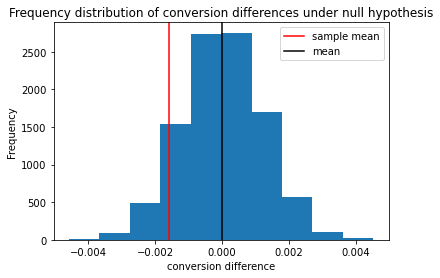

In [153]:
freq_dist()
plt.axvline(0, c='black')
plt.legend(['sample mean', 'mean'])
print('The distance between the black to the red line is -1.3109 standard deviations which is the Z-score.')
print('The p value is represented by everything to the right of the red line.')

<a id='regression'></a>
### Part III - A regression approach

### ToDo 3.1 

**a.** Using logistic regression to perform A/B test. Logistic regression is chosen because there are only two values that are being measured.

**b.** Creating appropriate columns to perform logistic regression:
 1. `intercept` - It should be `1` in the entire column. 
 2. `ab_page` - It's a dummy variable column, having a value `1` when an individual receives the **treatment**, otherwise `0`.  

In [154]:
df2['intercept'] = 1
df2[['other', 'ab_page']] = pd.get_dummies(df2['group'])
df2 = df2.drop('other', axis=1)

**c.** Uses **statsmodels** to instantiate regression model on the two columns created in part (b). above, then fits the model to predict whether or not an individual converts. 

In [155]:
log_mod = sm.Logit(df2['converted'], df2[['intercept', 'ab_page']])
results = log_mod.fit()

Optimization terminated successfully.
         Current function value: 0.366118
         Iterations 6


**d.** Summary

In [156]:
results.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Results: Logit
==================================================================
Model:              Logit            Pseudo R-squared: 0.000      
Dependent Variable: converted        AIC:              212780.3502
Date:               2022-04-10 01:51 BIC:              212801.5095
No. Observations:   290584           Log-Likelihood:   -1.0639e+05
Df Model:           1                LL-Null:          -1.0639e+05
Df Residuals:       290582           LLR p-value:      0.18988    
Converged:          1.0000           Scale:            1.0000     
No. Iterations:     6.0000                                        
-------------------------------------------------------------------
              Coef.   Std.Err.      z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
intercept    -1.9888    0.0081  -246.6690  0.0000  -2.0046  -1.9730
ab_page      -0.0150    0.0114    -1.3109  0.1899  -0.0374   0.0074
==================================================================

"""

**e.** Explanation of differences in P values.


>**The P value is 0.190. The value differs from Part II because in part II the p value was caluculated using a one-tail test and rather than a two tail test in this part and because the null and alternative hypothesis were flipped most likely becuase the ab_page had a 1 for treatment and 0 for control.**

At this point:
	the null hypothesis is that there is a difference in conversion 
	the alternative is that there isn't a difference in conversion

The p value calcuated above represents everything outside of the red lines.


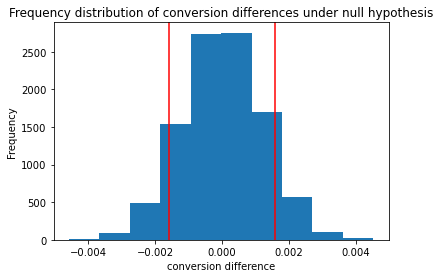

In [157]:
freq_dist()
plt.axvline(abs(actual_conversion_diff), c='r')
print("At this point:\n\tthe null hypothesis is that there is a difference in conversion \n\tthe alternative is that there isn't a difference in conversion\n")
print('The p value calcuated above represents everything outside of the red lines.')

**f.** Considering other factors.

>**Adding more factors the model can be made more accurate, but with that comes things like multicollinearity that need to be accounted for.**

**g. Adding countries**<br> 
Now along with testing if the conversion rate changes for different pages, which user a country a user lives in will be added as a factor.

1. The **countries.csv** will be read and then merged with `df2` to create a dataframe called `df_merged`

2. Results will be shown for whether country had an effect on conversion.

In [158]:
# Read the countries.csv
df3 = pd.read_csv('countries.csv')

In [159]:
# Join with the df2 dataframe
df_merged = df2.set_index('user_id').join(df3.set_index('user_id'))

In [160]:
# Create the necessary dummy variables
df_merged[['CA', 'UK', 'US']] = pd.get_dummies(df_merged['country'])

In [161]:
logit_mod = sm.Logit(df_merged['converted'], df_merged[['intercept', 'ab_page', 'CA', 'UK']])
results = logit_mod.fit()
results.summary2()

Optimization terminated successfully.
         Current function value: 0.366113
         Iterations 6


<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Results: Logit
==================================================================
Model:              Logit            Pseudo R-squared: 0.000      
Dependent Variable: converted        AIC:              212781.1253
Date:               2022-04-10 01:51 BIC:              212823.4439
No. Observations:   290584           Log-Likelihood:   -1.0639e+05
Df Model:           3                LL-Null:          -1.0639e+05
Df Residuals:       290580           LLR p-value:      0.17599    
Converged:          1.0000           Scale:            1.0000     
No. Iterations:     6.0000                                        
-------------------------------------------------------------------
              Coef.   Std.Err.      z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
intercept    -1.9893    0.0089  -223.7628  0.0000  -2.0067  -1.9718
ab_page      -0.0149    0.0114    -1.3069  0.1912  -0.0374   0.0075
CA           -0.0408    0.0269    -1.5161  0.1295  -0.0934   0.0119
UK            0.0099    0.0133     0.7433  0.4573  -0.0162   0.0359
==================================================================

"""

>**It does not appear that country had an impact on conversion based on the type I error rate because the p values are all greater than 0.05. For the UK especially there is a 46% chance that the values generated could have happened under the null hypothesis meaning that it is about 50:50 that the values could have fallen under the null or alternative hypothesis. The p value for CA is the lowest so far at 0.13.**

**h. Fit your model and obtain the results**<br> 
Though you have now looked at the individual factors of country and page on conversion, we would now like to look at an interaction between page and country to see if are there significant effects on conversion.  **Create the necessary additional columns, and fit the new model.** 


Provide the summary results (statistical output), and your conclusions (written response) based on the results. 


In [162]:
# creating interactive variables
df_merged['UK_inter'] = df_merged.UK * df_merged.ab_page
df_merged['CA_inter'] = df_merged.CA * df_merged.ab_page

In [163]:
logit_mod = sm.Logit(df_merged['converted'], df_merged[['intercept', 'ab_page', 'CA', 'UK', 'UK_inter', 'CA_inter']])
results = logit_mod.fit()
results.summary2()

Optimization terminated successfully.
         Current function value: 0.366109
         Iterations 6


<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Results: Logit
==================================================================
Model:              Logit            Pseudo R-squared: 0.000      
Dependent Variable: converted        AIC:              212782.6602
Date:               2022-04-10 01:51 BIC:              212846.1381
No. Observations:   290584           Log-Likelihood:   -1.0639e+05
Df Model:           5                LL-Null:          -1.0639e+05
Df Residuals:       290578           LLR p-value:      0.19199    
Converged:          1.0000           Scale:            1.0000     
No. Iterations:     6.0000                                        
-------------------------------------------------------------------
              Coef.   Std.Err.      z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
intercept    -1.9865    0.0096  -206.3440  0.0000  -2.0053  -1.9676
ab_page      -0.0206    0.0137    -1.5052  0.1323  -0.0473   0.0062
CA           -0.0175    0.0377    -0.4652  0.6418  -0.0914   0.0563
UK           -0.0057    0.0188    -0.3057  0.7598  -0.0426   0.0311
UK_inter      0.0314    0.0266     1.1807  0.2377  -0.0207   0.0835
CA_inter     -0.0469    0.0538    -0.8718  0.3833  -0.1523   0.0585
==================================================================

"""

>**Based on these results the null hypothesis can not be rejected using the decided upon Type I error rate of 0.05 because none of the p values are below it. Adding the interactive variables has improved the p value for ab_page to 0.13, but worsened the p value for CA to 0.64 and UK to 0.76 though none of the values are close to approaching 0.05. If the Type I error rate was raised the value that would pass first is CA without the interactive variables included. None of the values are statistically significant and it can be concluded that the treatment is not effective.**